In [1]:
import librosa
import numpy as np
import matplotlib.pyplot as plt

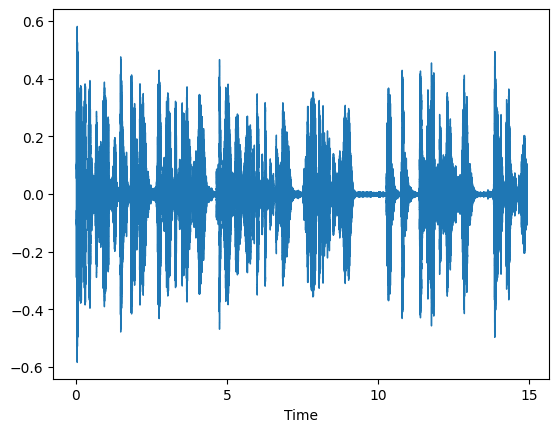

In [2]:
y, sr = librosa.load('chords-test/audio.wav', sr=22050)

librosa.display.waveshow(y, sr=sr, axis='time', )

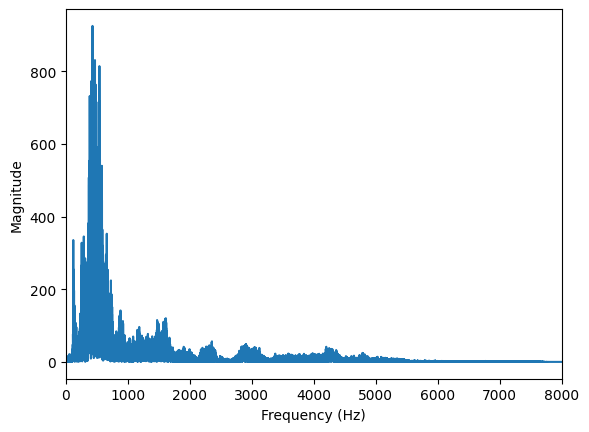

In [3]:
# # FFT of the whole signal
spectrum = np.abs(np.fft.rfft(y))
freqs = np.fft.rfftfreq(len(y), d=1/sr)

plt.plot(freqs, spectrum)
plt.xlim(0, 8000)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.show()

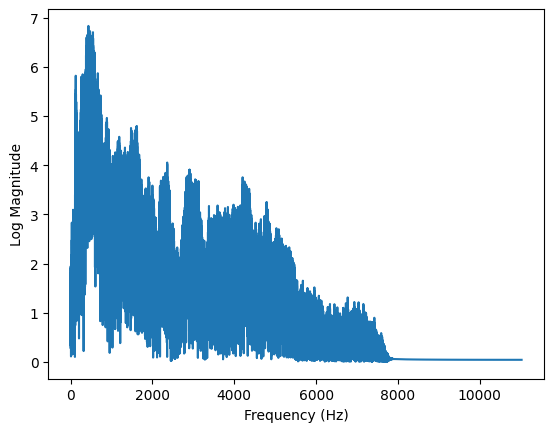

In [4]:
# Log scale the FFT
spectrum_log = np.log1p(spectrum)

plt.plot(freqs, spectrum_log)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Log Magnitude")
plt.show()


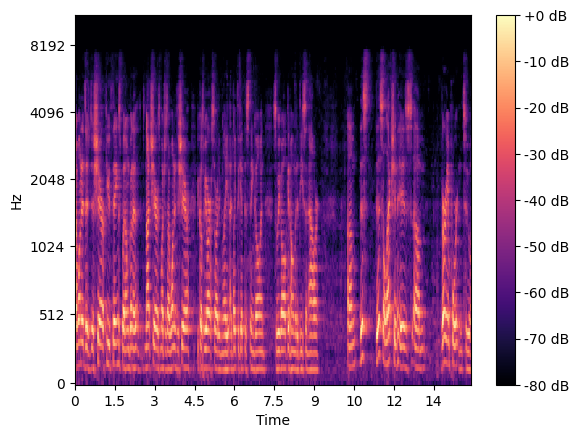

In [7]:
# Create a Mel spectrogram
mel_spectrogram = librosa.feature.melspectrogram(y=y, sr=sr)
librosa.display.specshow(librosa.power_to_db(mel_spectrogram, ref=np.max), sr=sr, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.show()

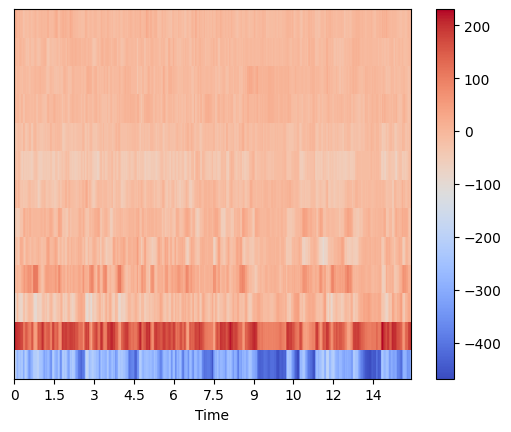

In [13]:
# Apply DCT to the mel spectrum to get MFCCs
mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)

librosa.display.specshow(mfccs, sr=sr, x_axis='time')
plt.colorbar()

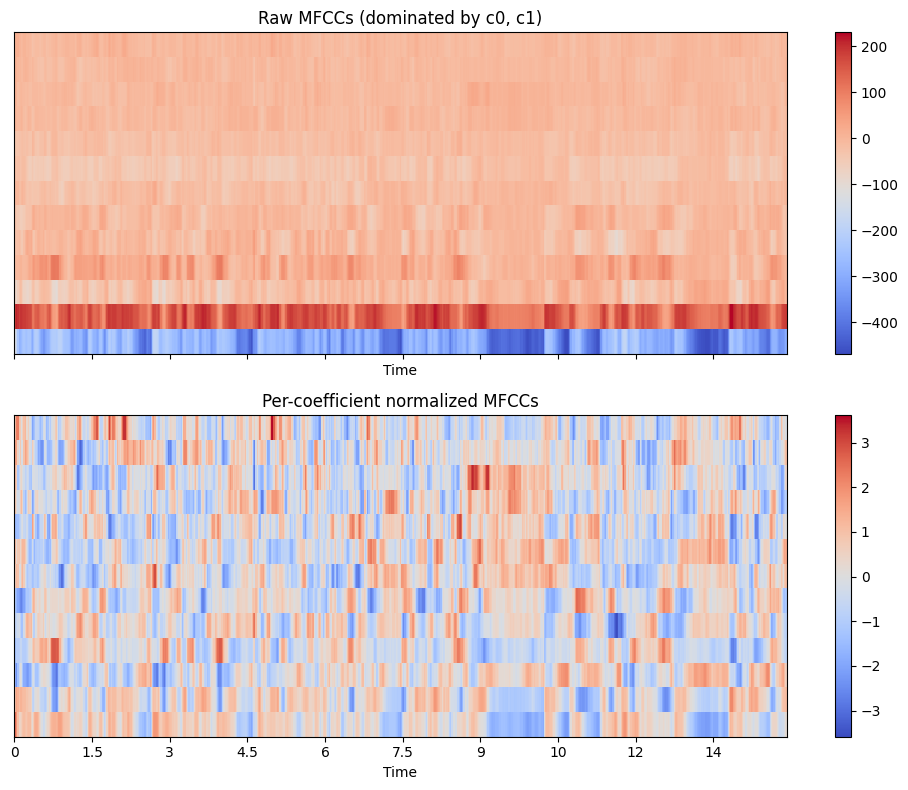

In [14]:
# Normalize the MFCCs
# Compute MFCCs
mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)

# Z-score normalize each coefficient (row) independently
mfccs_norm = (mfccs - mfccs.mean(axis=1, keepdims=True)) / mfccs.std(axis=1, keepdims=True)

fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

img1 = librosa.display.specshow(mfccs, sr=sr, x_axis='time', ax=ax[0])
ax[0].set_title('Raw MFCCs (dominated by c0, c1)')
fig.colorbar(img1, ax=ax[0])

img2 = librosa.display.specshow(mfccs_norm, sr=sr, x_axis='time', ax=ax[1], cmap='coolwarm')
ax[1].set_title('Per-coefficient normalized MFCCs')
fig.colorbar(img2, ax=ax[1])

plt.tight_layout()
plt.show()